<a href="https://colab.research.google.com/github/Aya-hassan101/ML_portfolio/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [ ]:
#import the datasets
data=pd.read_csv('/content/data.csv')

In [ ]:
data.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [ ]:
data.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [ ]:
for column in data.select_dtypes(include='object').columns:
   data[column]=data[column].astype('category').cat.codes
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   int8   
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   int16  
 15  city           4600 non-null   int8   
 16  statezip       4600 non-null   int8   
 17  country        4600 non-null   int8   
dtypes: float

In [ ]:
data.corr()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
date,1.000000,0.033906,0.005762,0.019263,0.029481,-0.020393,0.029607,0.017586,0.005844,0.007853,0.041038,-0.015050,0.001356,-0.018437,-0.005089,-0.020325,-0.004546,NaN
price,0.033906,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774,0.029366,0.018625,-0.043385,NaN
bedrooms,0.005762,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082,-0.035507,-0.130447,-0.152773,NaN
bathrooms,0.019263,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886,0.007175,-0.097026,-0.194497,NaN
sqft_living,0.029481,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817,0.006411,-0.109686,-0.198918,NaN
sqft_lot,-0.020393,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730,-0.023028,-0.079135,-0.128466,NaN
floors,0.029607,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996,0.056191,0.078481,-0.038943,NaN
waterfront,0.017586,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625,0.035448,0.001450,0.007938,NaN
view,0.005844,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967,0.065077,0.001340,0.079340,NaN
condition,0.007853,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818,-0.005480,-0.010592,0.027666,NaN


In [ ]:
data.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
count,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.0
mean,36.135217,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,2265.385870,25.674348,38.743696,0.0
std,19.708177,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,1307.591795,11.982721,20.919517,0.0
min,0.000000,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,19.000000,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,1132.750000,17.000000,21.000000,0.0
50%,38.000000,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,2263.500000,32.000000,41.000000,0.0
75%,53.000000,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,3400.250000,35.000000,56.000000,0.0
max,69.000000,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,4524.000000,43.000000,76.000000,0.0


In [ ]:
X=data.drop(['price'],axis=1)
Y=data['price']

In [ ]:
print(X)
print(Y)

      date  bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  \
0        0       3.0       1.50         1340      7912     1.5           0   
1        0       5.0       2.50         3650      9050     2.0           0   
2        0       3.0       2.00         1930     11947     1.0           0   
3        0       3.0       2.25         2000      8030     1.0           0   
4        0       4.0       2.50         1940     10500     1.0           0   
...    ...       ...        ...          ...       ...     ...         ...   
4595    68       3.0       1.75         1510      6360     1.0           0   
4596    68       3.0       2.50         1460      7573     2.0           0   
4597    68       3.0       2.50         3010      7014     2.0           0   
4598    69       4.0       2.00         2090      6630     1.0           0   
4599    69       3.0       2.50         1490      8102     2.0           0   

      view  condition  sqft_above  sqft_basement  yr_built  yr_

In [ ]:
X_train,X_text,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)

In [ ]:
print(X.shape,X_train.shape,X_text.shape)

(4600, 17) (3680, 17) (920, 17)


Training the model

XGBoost Regressor

In [ ]:
model=XGBRegressor()


In [ ]:
#traing the model
model.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

Evaluation

Predict on training

In [ ]:
data_prediction=model.predict(X_train)

In [ ]:
model.score(X_train,Y_train)

0.9904498399395483

In [ ]:
print(data_prediction)

[510493.56 260965.78 539911.56 ... 415424.53 325151.8  618985.1 ]


In [ ]:
# R squared error
score_1 = metrics.r2_score(Y_train,data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_train,data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.9904498399395483
Mean Absolute Error :  29573.739681543273


Visulalizing the actula training and predicted training

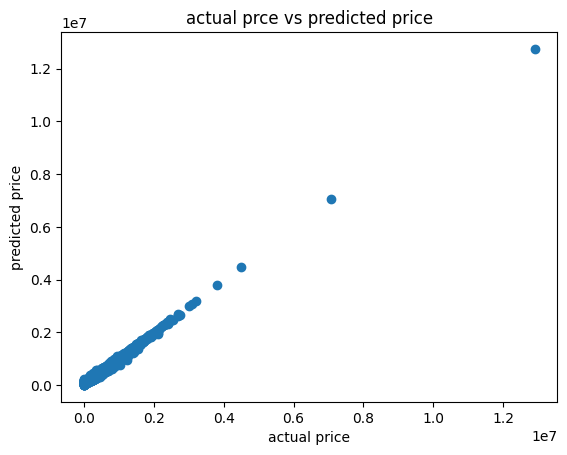

In [ ]:
plt.scatter(Y_train,data_prediction)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual prce vs predicted price")
plt.show()

Prediction on test data

In [ ]:
test_data_prediction=model.predict(X_text)

In [ ]:
# R squared error
score_1 = metrics.r2_score(Y_test,test_data_prediction)

# Mean Absolute Error
score_2 = metrics.mean_absolute_error(Y_test,test_data_prediction)

print("R squared error : ", score_1)
print('Mean Absolute Error : ', score_2)

R squared error :  0.040437566862472574
Mean Absolute Error :  152689.9230701777


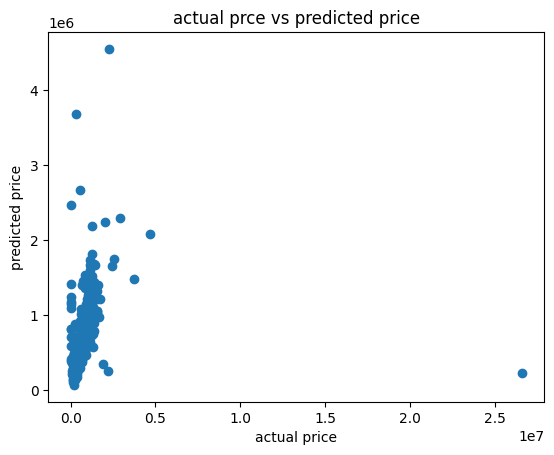

In [ ]:
plt.scatter(Y_test,test_data_prediction)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual prce vs predicted price")
plt.show()

### Addressing Overfitting: Hyperparameter Tuning

Overfitting is a common problem in machine learning where a model learns the training data too well, capturing noise and specific patterns that are not representative of the general data distribution. This leads to high performance on the training set but poor performance on unseen test data.

To mitigate overfitting in XGBoost, we can tune its hyperparameters. Key hyperparameters that control model complexity and prevent overfitting include:
- `n_estimators`: The number of boosting rounds or trees to build. Too many can lead to overfitting.
- `max_depth`: The maximum depth of a tree. Deeper trees can capture more specific patterns but are prone to overfitting.
- `learning_rate` (or `eta`): Step size shrinkage used to prevent overfitting. Smaller values require more estimators but make the model more robust.
- `subsample`: Fraction of samples used for fitting the trees. Helps reduce variance.
- `colsample_bytree`: Fraction of features used for fitting the trees. Helps reduce variance.
- `gamma`: Minimum loss reduction required to make a further partition on a leaf node of the tree. Larger values make the model more conservative.

We will use `GridSearchCV` from `sklearn.model_selection` to systematically search for the best combination of these hyperparameters.

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor # Added import to ensure XGBRegressor is defined

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Initialize the XGBoost Regressor model
model = XGBRegressor(random_state=2)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='r2',
    cv=3, # Using 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, Y_train)

# Print the best parameters and the best score
print("Best parameters found: ", grid_search.best_params_)
print("Best R-squared score found: ", grid_search.best_score_)

# Get the best model
best_model = grid_search.best_estimator_

NameError: name 'XGBRegressor' is not defined

### Re-evaluating the Model with Best Parameters

Now that we have found the optimal hyperparameters, we will evaluate the performance of the model with these new parameters on both the training and test datasets. This will help us determine if the hyperparameter tuning has successfully reduced overfitting and improved the model's generalization capabilities.

In [ ]:
# Predict on training data with the best model
train_data_prediction_tuned = best_model.predict(X_train)

# R squared error on training data
score_1_tuned_train = metrics.r2_score(Y_train, train_data_prediction_tuned)

# Mean Absolute Error on training data
score_2_tuned_train = metrics.mean_absolute_error(Y_train, train_data_prediction_tuned)

print("--- Tuned Model Performance on Training Data ---")
print("R squared error (Training) : ", score_1_tuned_train)
print('Mean Absolute Error (Training) : ', score_2_tuned_train)

# Predict on test data with the best model
test_data_prediction_tuned = best_model.predict(X_text)

# R squared error on test data
score_1_tuned_test = metrics.r2_score(Y_test, test_data_prediction_tuned)

# Mean Absolute Error on test data
score_2_tuned_test = metrics.mean_absolute_error(Y_test, test_data_prediction_tuned)

print("\n--- Tuned Model Performance on Test Data ---")
print("R squared error (Test) : ", score_1_tuned_test)
print('Mean Absolute Error (Test) : ', score_2_tuned_test)

NameError: name 'best_model' is not defined

### Visualizing Actual vs. Predicted Prices with Tuned Model

Let's visualize the actual prices against the predicted prices for both the training and test datasets using the model with tuned hyperparameters. This will provide a visual assessment of how well the improved model is performing.

In [ ]:
import matplotlib.pyplot as plt # Added import to ensure plt is defined

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(Y_train, train_data_prediction_tuned)
plt.xlabel("Actual Price (Training)")
plt.ylabel("Predicted Price (Training)")
plt.title("Tuned Model: Actual vs. Predicted Price (Training Data)")

plt.subplot(1, 2, 2)
plt.scatter(Y_test, test_data_prediction_tuned)
plt.xlabel("Actual Price (Test)")
plt.ylabel("Predicted Price (Test)")
plt.title("Tuned Model: Actual vs. Predicted Price (Test Data)")

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined